In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/Crop yeild Datsets.csv')

In [ ]:
df.head()

,State,Year,crop,yield,rainfall,Avg_Temperature,Area,Production,soil_type,Climate_Zone,Avg_Summer_Temp_C,Avg_Winter_Temp_C,Irrigation_Coverage_%,Groundwater_Availability,Cropping_Intensity_%,N,P,K,pH,Humidity
0,Puducherry,2011,arecanut,1.280,1434.588,27.938,60.0,77,Coastal Alluvial Soil,Tropical Wet-Dry,34.0,18.0,80.0,High,170.0,60.670768,27.928901,44.989089,6.270898,75.417957
1,Puducherry,2011,bajra,2.640,1434.588,27.938,11.0,29,Coastal Alluvial Soil,Tropical Wet-Dry,34.0,18.0,80.0,High,170.0,60.670768,27.928901,44.989089,6.270898,75.417957
2,Puducherry,2011,bajra,2.550,1434.588,27.938,20.0,51,Coastal Alluvial Soil,Tropical Wet-Dry,34.0,18.0,80.0,High,170.0,60.670768,27.928901,44.989089,6.270898,75.417957
3,Puducherry,2011,banana,10.903,1434.588,27.938,266.0,3263,Coastal Alluvial Soil,Tropical Wet-Dry,34.0,18.0,80.0,High,170.0,60.670768,27.928901,44.989089,6.270898,75.417957
4,Puducherry,2011,black pepper,0.450,1434.588,27.938,11.0,5,Coastal Alluvial Soil,Tropical Wet-Dry,34.0,18.0,80.0,High,170.0,60.670768,27.928901,44.989089,6.270898,75.417957


Basic Structure Check

In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isna().sum())

print("\nData Types:")
print(df.dtypes)

Shape: (8988, 20)

Columns:
['State', 'Year', 'crop', 'yield', 'rainfall', 'Avg_Temperature', 'Area', 'Production', 'soil_type', 'Climate_Zone', 'Avg_Summer_Temp_C', 'Avg_Winter_Temp_C', 'Irrigation_Coverage_%', 'Groundwater_Availability', 'Cropping_Intensity_%', 'N', 'P', 'K', 'pH', 'Humidity']

Missing Values:
State                         0
Year                          0
crop                          0
yield                         0
rainfall                      0
Avg_Temperature               0
Area                          0
Production                    0
soil_type                   180
Climate_Zone                180
Avg_Summer_Temp_C           180
Avg_Winter_Temp_C           180
Irrigation_Coverage_%       180
Groundwater_Availability    180
Cropping_Intensity_%        180
N                             0
P                             0
K                             0
pH                            0
Humidity                      0
dtype: int64

Data Types:
State               

Clean Text columns

In [ ]:
# Strip column names
df.columns = df.columns.str.strip()

# Strip string columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

df.head()

,State,Year,crop,yield,rainfall,Avg_Temperature,Area,Production,soil_type,Climate_Zone,Avg_Summer_Temp_C,Avg_Winter_Temp_C,Irrigation_Coverage_%,Groundwater_Availability,Cropping_Intensity_%,N,P,K,pH,Humidity
0,Puducherry,2011,arecanut,1.280,1434.588,27.938,60.0,77,Coastal Alluvial Soil,Tropical Wet-Dry,34.0,18.0,80.0,High,170.0,60.670768,27.928901,44.989089,6.270898,75.417957
1,Puducherry,2011,bajra,2.640,1434.588,27.938,11.0,29,Coastal Alluvial Soil,Tropical Wet-Dry,34.0,18.0,80.0,High,170.0,60.670768,27.928901,44.989089,6.270898,75.417957
2,Puducherry,2011,bajra,2.550,1434.588,27.938,20.0,51,Coastal Alluvial Soil,Tropical Wet-Dry,34.0,18.0,80.0,High,170.0,60.670768,27.928901,44.989089,6.270898,75.417957
3,Puducherry,2011,banana,10.903,1434.588,27.938,266.0,3263,Coastal Alluvial Soil,Tropical Wet-Dry,34.0,18.0,80.0,High,170.0,60.670768,27.928901,44.989089,6.270898,75.417957
4,Puducherry,2011,black pepper,0.450,1434.588,27.938,11.0,5,Coastal Alluvial Soil,Tropical Wet-Dry,34.0,18.0,80.0,High,170.0,60.670768,27.928901,44.989089,6.270898,75.417957


Remove Duplicates

In [ ]:
before = len(df)
df = df.drop_duplicates()
after = len(df)

print("Duplicates removed:", before - after)

Duplicates removed: 6


Fixed Datatypes

In [ ]:
# Convert numeric columns safely
numeric_columns = df.select_dtypes(include=["float64","int64"]).columns

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

Handle Missing Values

In [ ]:
print("Missing before fix:\n", df.isna().sum())

# Fill numeric with median
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical with mode
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing after fix:\n", df.isna().sum())

Missing before fix:
 State                         0
Year                          0
crop                          0
yield                         0
rainfall                      0
Avg_Temperature               0
Area                          0
Production                    0
soil_type                   180
Climate_Zone                180
Avg_Summer_Temp_C           180
Avg_Winter_Temp_C           180
Irrigation_Coverage_%       180
Groundwater_Availability    180
Cropping_Intensity_%        180
N                             0
P                             0
K                             0
pH                            0
Humidity                      0
dtype: int64

Missing after fix:
 State                       0
Year                        0
crop                        0
yield                       0
rainfall                    0
Avg_Temperature             0
Area                        0
Production                  0
soil_type                   0
Climate_Zone                0
Avg_S

Remove Outliers

In [ ]:
Q1 = df["yield"].quantile(0.25)
Q3 = df["yield"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["yield"] = df["yield"].clip(lower, upper)

print("Outliers capped successfully")

Outliers capped successfully


Feature Engineering

In [ ]:
df["Yield_per_Rainfall"] = df["yield"] / (df["rainfall"] + 1)

In [ ]:
df["NPK_Total"] = df["N"] + df["P"] + df["K"]

In [ ]:
if "Avg_Summer_Temp_C" in df.columns and "Avg_Winter_Temp_C" in df.columns:
    df["Temp_Diff"] = df["Avg_Summer_Temp_C"] - df["Avg_Winter_Temp_C"]

In [ ]:
df["Log_Area"] = np.log1p(df["Area"])

Exploratory Data Analysis

Yeild Distribution

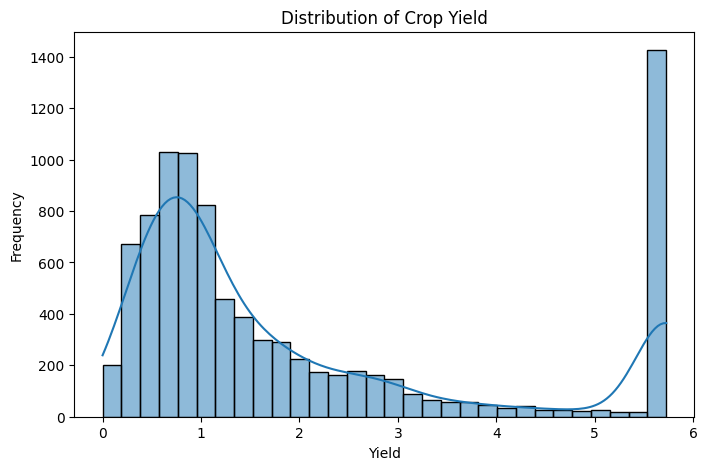

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["yield"], bins=30, kde=True)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

Yeild vs Rainfall

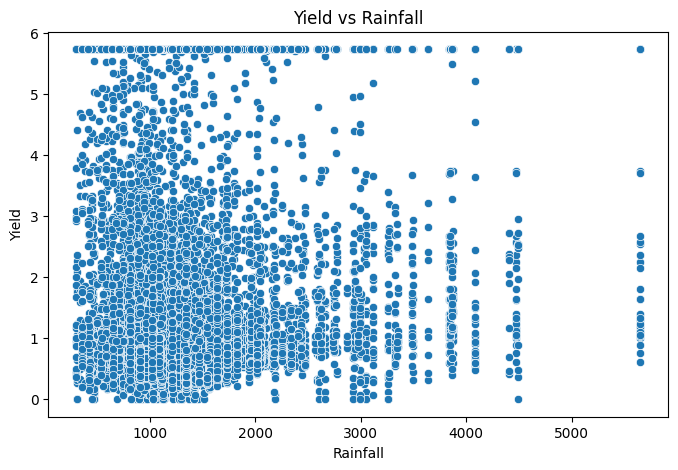

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["rainfall"], y=df["yield"])
plt.title("Yield vs Rainfall")
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.show()

Yeild vs Temperature

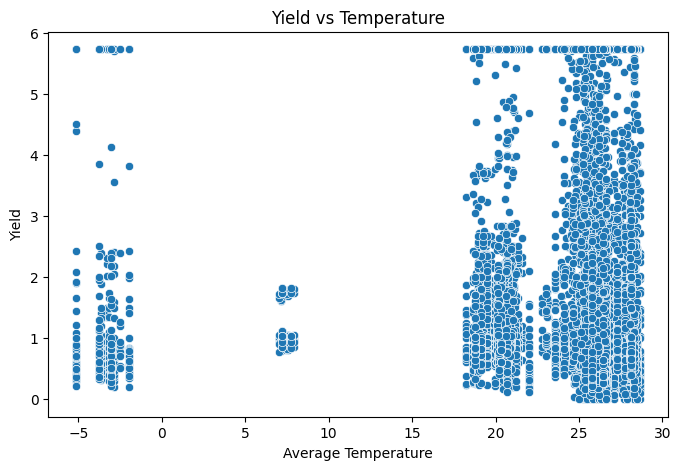

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Avg_Temperature"], y=df["yield"])
plt.title("Yield vs Temperature")
plt.xlabel("Average Temperature")
plt.ylabel("Yield")
plt.show()

NPK effect on Yeild

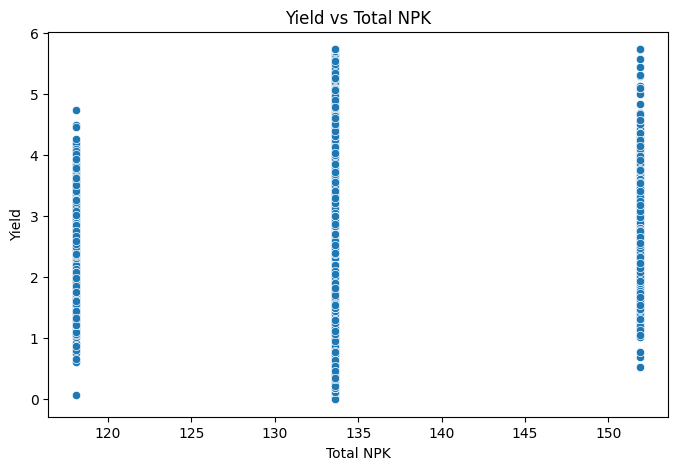

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["NPK_Total"], y=df["yield"])
plt.title("Yield vs Total NPK")
plt.xlabel("Total NPK")
plt.ylabel("Yield")
plt.show()

correlation Heatmap

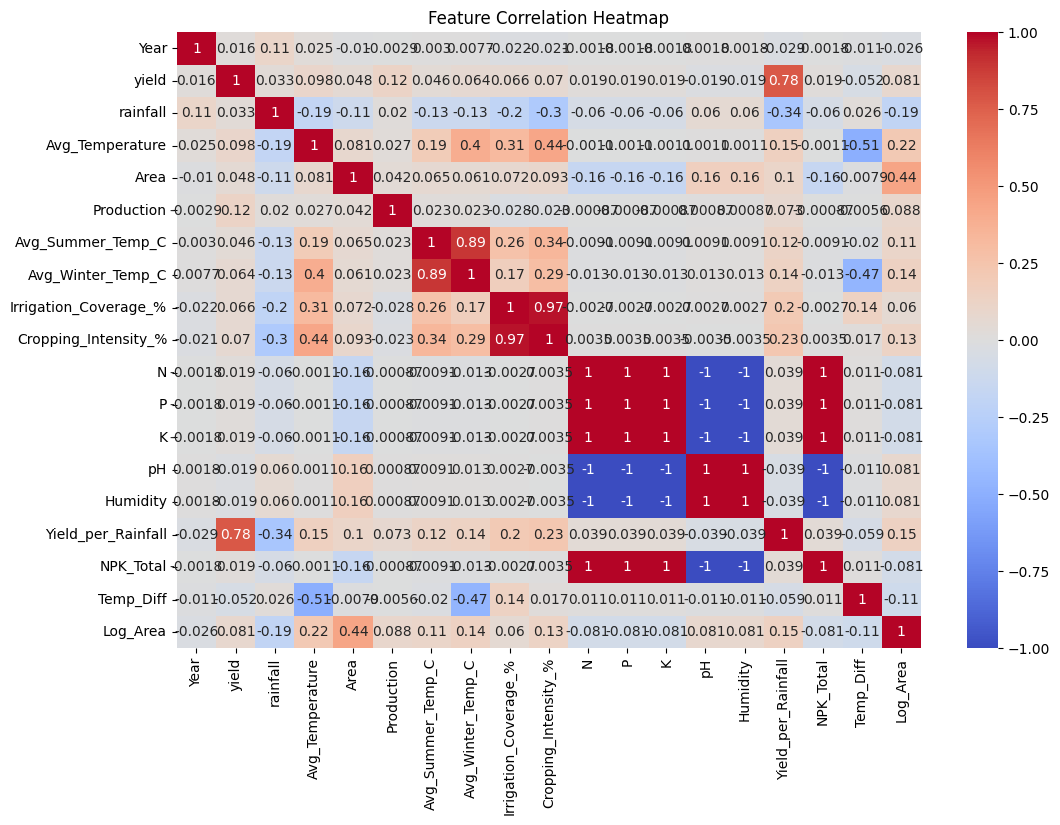

In [ ]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['float64','int64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

Yeild by crop

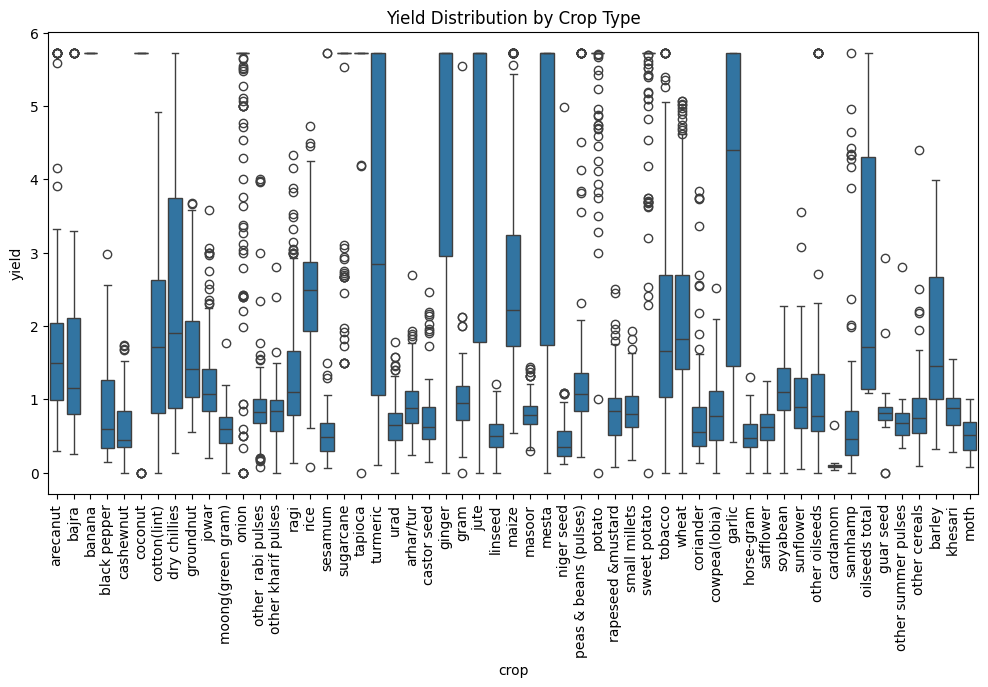

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x=df["crop"], y=df["yield"])
plt.xticks(rotation=90)
plt.title("Yield Distribution by Crop Type")
plt.show()

 Final Feature Selection for Website Model

In [ ]:
final_features = [
    "State",
    "crop",
    "rainfall",
    "Avg_Temperature",
    "soil_type",
    "N",
    "P",
    "K",
    "pH",
    "Humidity"
]

target = "yield"

df_final_model = df[final_features + [target]].copy()

df_final_model.head()

,State,crop,rainfall,Avg_Temperature,soil_type,N,P,K,pH,Humidity,yield
0,Puducherry,arecanut,1434.588,27.938,Coastal Alluvial Soil,60.670768,27.928901,44.989089,6.270898,75.417957,1.280000
1,Puducherry,bajra,1434.588,27.938,Coastal Alluvial Soil,60.670768,27.928901,44.989089,6.270898,75.417957,2.640000
2,Puducherry,bajra,1434.588,27.938,Coastal Alluvial Soil,60.670768,27.928901,44.989089,6.270898,75.417957,2.550000
3,Puducherry,banana,1434.588,27.938,Coastal Alluvial Soil,60.670768,27.928901,44.989089,6.270898,75.417957,5.726625
4,Puducherry,black pepper,1434.588,27.938,Coastal Alluvial Soil,60.670768,27.928901,44.989089,6.270898,75.417957,0.450000


In [ ]:
print(df_final_model.isna().sum())

State              0
crop               0
rainfall           0
Avg_Temperature    0
soil_type          0
N                  0
P                  0
K                  0
pH                 0
Humidity           0
yield              0
dtype: int64


Encode Categorial Variables

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

print("New Shape after encoding:", df_encoded.shape)

New Shape after encoding: (8982, 123)


seeing if cleaning done

In [ ]:
df_encoded.isna().sum().sum()
np.int64(0)

np.int64(0)

In [ ]:
display(df_encoded)

,Year,yield,rainfall,Avg_Temperature,Area,Production,Avg_Summer_Temp_C,Avg_Winter_Temp_C,Irrigation_Coverage_%,Cropping_Intensity_%,...,soil_type_Red Soil,Climate_Zone_Humid Subtropical,Climate_Zone_Humid Subtropical/Alpine,Climate_Zone_Subtropical,Climate_Zone_Subtropical Semi-Arid,Climate_Zone_Temperate/Alpine,Climate_Zone_Tropical Monsoon,Climate_Zone_Tropical Wet-Dry,Groundwater_Availability_Low,Groundwater_Availability_Medium
0,2011,1.280000,1434.588,27.938,60.0,77,34.0,18.0,80.0,170.0,...,False,False,False,False,False,False,False,True,False,False
1,2011,2.640000,1434.588,27.938,11.0,29,34.0,18.0,80.0,170.0,...,False,False,False,False,False,False,False,True,False,False
2,2011,2.550000,1434.588,27.938,20.0,51,34.0,18.0,80.0,170.0,...,False,False,False,False,False,False,False,True,False,False
3,2011,5.726625,1434.588,27.938,266.0,3263,34.0,18.0,80.0,170.0,...,False,False,False,False,False,False,False,True,False,False
4,2011,0.450000,1434.588,27.938,11.0,5,34.0,18.0,80.0,170.0,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8983,2018,5.726625,1635.900,25.785,6778.0,417672,30.0,20.0,35.0,130.0,...,False,False,False,False,False,False,True,False,False,True
8984,2018,0.337000,1635.900,25.785,13720.0,3583,30.0,20.0,35.0,130.0,...,False,False,False,False,False,False,True,False,False,True
8985,2018,0.469000,1635.900,25.785,4571.0,2336,30.0,20.0,35.0,130.0,...,False,False,False,False,False,False,True,False,False,True
8986,2018,0.353000,1635.900,25.785,39560.0,13123,30.0,20.0,35.0,130.0,...,False,False,False,False,False,False,True,False,False,True


Importing Ml libraries

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

Target value Yeild

In [ ]:
y = df_encoded["yield"]
X = df_encoded.drop("yield", axis=1)

Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (7185, 122)
Testing size: (1797, 122)


Train Model (Linear Regression)

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

Evaluate Linear Regression

In [ ]:
print("Linear Regression Performance")

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Performance
MAE: 0.4224309171701696
RMSE: 0.6279535702744516
R2 Score: 0.8865710041032976


Train Decision Tree

In [ ]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

Evaluate Decision Tree

In [ ]:
print("Decision Tree Performance")

print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2 Score:", r2_score(y_test, y_pred_dt))

Decision Tree Performance
MAE: 0.044296048970507554
RMSE: 0.1220959749570946
R2 Score: 0.9957118327675071


Train Random Forest

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Evaluate Random Forest

In [ ]:
print("Random Forest Performance")

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Performance
MAE: 0.028745080342236825
RMSE: 0.0958459645357108
R2 Score: 0.9973574897287081


Feature Importance

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance.head(15)

,Feature,Importance
14,Yield_per_Rainfall,0.791142
1,rainfall,0.196252
50,crop_barley,0.001046
4,Production,0.000980
3,Area,0.000945
17,Log_Area,0.000927
12,pH,0.000708
13,Humidity,0.000658
11,K,0.000616
10,P,0.000593


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

Train Xgboost Model

In [ ]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

Evaluate xgboost Model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("XGBoost Performance")

print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2 Score:", r2_score(y_test, y_pred_xgb))

XGBoost Performance
MAE: 0.030376830123468198
RMSE: 0.08236689469175575
R2 Score: 0.9980484737129596


Model Comparision Table

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "XGBoost"],

    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ],

    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.422431,0.627954,0.886571
1,Decision Tree,0.044296,0.122096,0.995712
2,Random Forest,0.028745,0.095846,0.997357
3,XGBoost,0.030377,0.082367,0.998048


Best model Selection

In [ ]:
results.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
3,XGBoost,0.030377,0.082367,0.998048
2,Random Forest,0.028745,0.095846,0.997357
1,Decision Tree,0.044296,0.122096,0.995712
0,Linear Regression,0.422431,0.627954,0.886571


feature importance of xgboost

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance.head(15)

,Feature,Importance
14,Yield_per_Rainfall,0.657681
1,rainfall,0.186710
9,N,0.035231
50,crop_barley,0.032647
57,crop_cotton(lint),0.028233
63,crop_groundnut,0.010571
85,crop_ragi,0.004554
100,crop_wheat,0.004498
56,crop_coriander,0.003716
113,Climate_Zone_Humid Subtropical,0.003689


shap installation

In [ ]:
!pip install shap

In [ ]:
import shap

Shap Analysis

In [ ]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

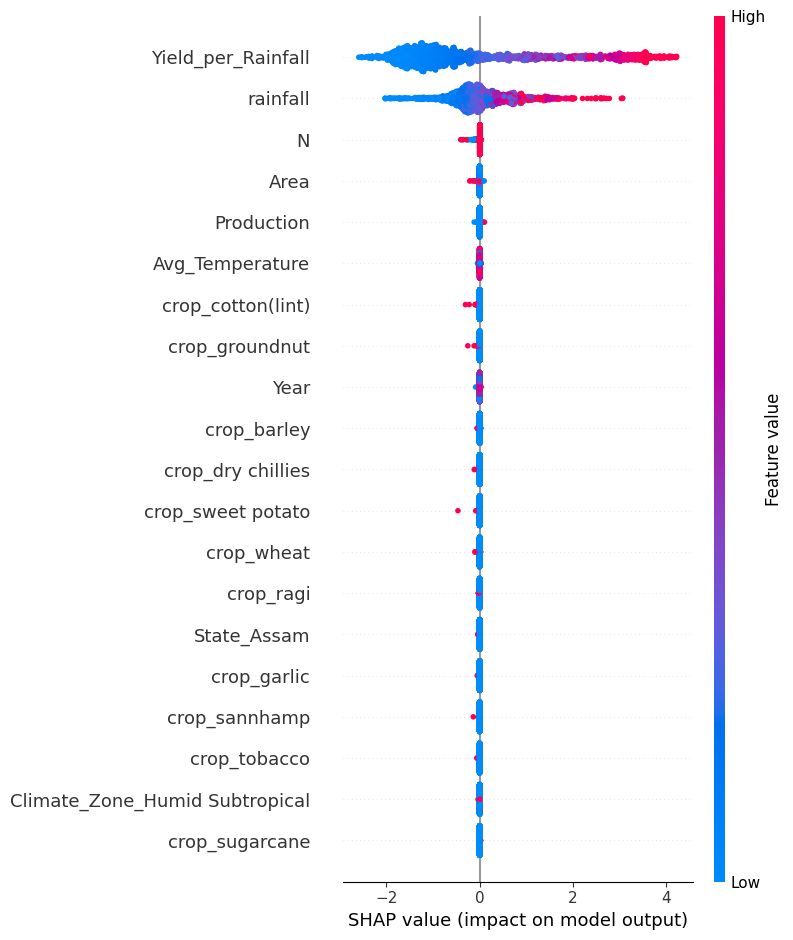

In [ ]:
shap.summary_plot(shap_values, X_test)

checking percent

In [ ]:
Evaluatet all models together

SyntaxError: invalid syntax (341471957.py, line 1)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "XGBoost"],

    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ],

    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ]
})

# Convert R2 to percentage
results["Accuracy (%)"] = results["R2 Score"] * 100

results

,Model,MAE,RMSE,R2 Score,Accuracy (%)
0,Linear Regression,0.422431,0.627954,0.886571,88.657100
1,Decision Tree,0.044296,0.122096,0.995712,99.571183
2,Random Forest,0.028745,0.095846,0.997357,99.735749
3,XGBoost,0.030377,0.082367,0.998048,99.804847


Models by best performance

In [ ]:
results.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score,Accuracy (%)
3,XGBoost,0.030377,0.082367,0.998048,99.804847
2,Random Forest,0.028745,0.095846,0.997357,99.735749
1,Decision Tree,0.044296,0.122096,0.995712,99.571183
0,Linear Regression,0.422431,0.627954,0.886571,88.657100


Model Comparision Graph

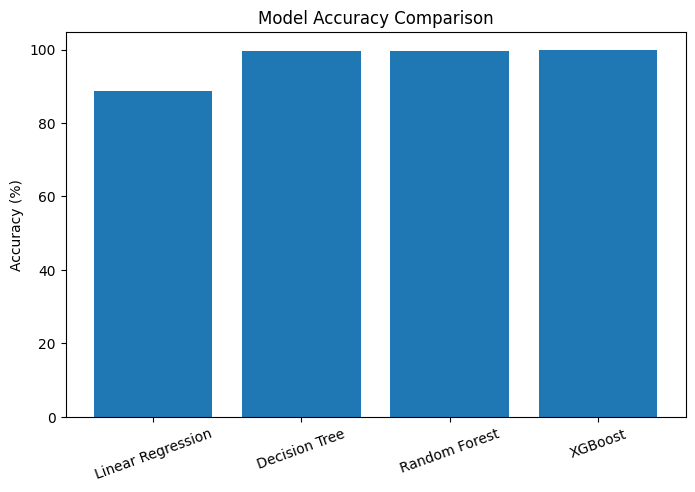

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy (%)"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=20)

plt.show()

Actual vs predicted values of all models

In [ ]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Linear Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
})

comparison_df.head(10)

,Actual,Linear Regression,Decision Tree,Random Forest,XGBoost
0,3.143,2.435426,3.125,3.190300,3.225181
1,0.200,0.150744,0.222,0.208005,0.201580
2,0.363,1.483758,0.350,0.360310,0.359896
3,0.598,0.901533,0.572,0.581275,0.591175
4,0.520,0.450780,0.518,0.511110,0.526336
5,0.580,0.941129,0.569,0.575285,0.579188
6,2.500,2.253194,2.531,2.498450,2.458199
7,1.754,1.648605,1.759,1.758245,1.723329
8,0.358,0.129627,0.362,0.359605,0.336267
9,0.491,0.726662,0.481,0.493160,0.501360


prediction error of all models

In [ ]:
error_df = pd.DataFrame({
    "Actual": y_test.values,
    "LR_Error": y_test.values - y_pred_lr,
    "DT_Error": y_test.values - y_pred_dt,
    "RF_Error": y_test.values - y_pred_rf,
    "XGB_Error": y_test.values - y_pred_xgb
})

error_df.head(10)

,Actual,LR_Error,DT_Error,RF_Error,XGB_Error
0,3.143,0.707574,0.018,-0.047300,-0.082181
1,0.200,0.049256,-0.022,-0.008005,-0.001580
2,0.363,-1.120758,0.013,0.002690,0.003104
3,0.598,-0.303533,0.026,0.016725,0.006825
4,0.520,0.069220,0.002,0.008890,-0.006336
5,0.580,-0.361129,0.011,0.004715,0.000812
6,2.500,0.246806,-0.031,0.001550,0.041801
7,1.754,0.105395,-0.005,-0.004245,0.030671
8,0.358,0.228373,-0.004,-0.001605,0.021733
9,0.491,-0.235662,0.010,-0.002160,-0.010360


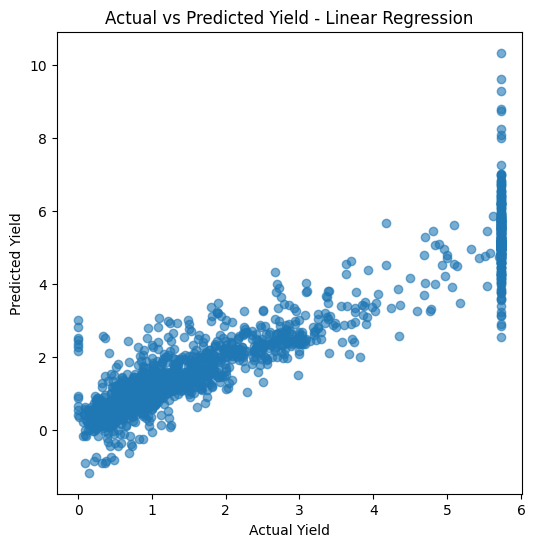

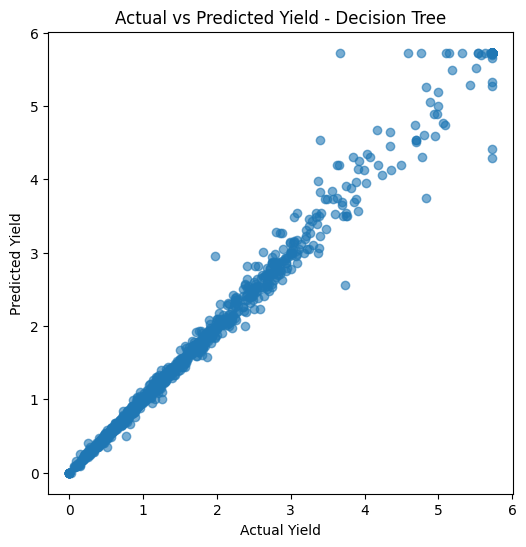

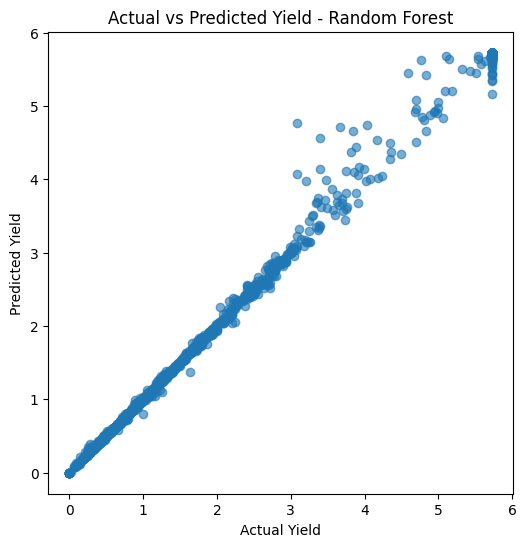

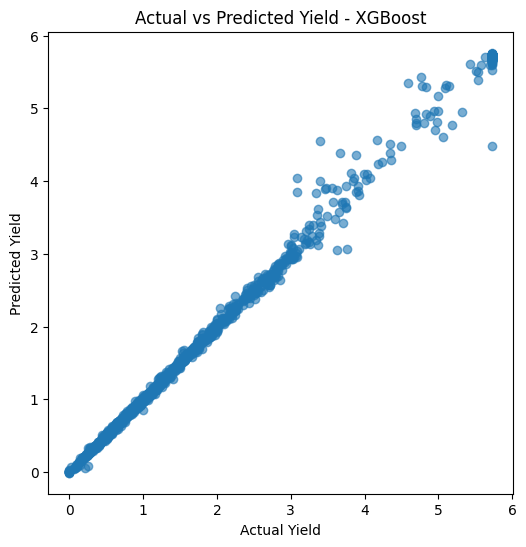

In [ ]:
import matplotlib.pyplot as plt

models = {
    "Linear Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for model_name, preds in models.items():
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, preds, alpha=0.6)
    plt.xlabel("Actual Yield")
    plt.ylabel("Predicted Yield")
    plt.title(f"Actual vs Predicted Yield - {model_name}")
    plt.show()

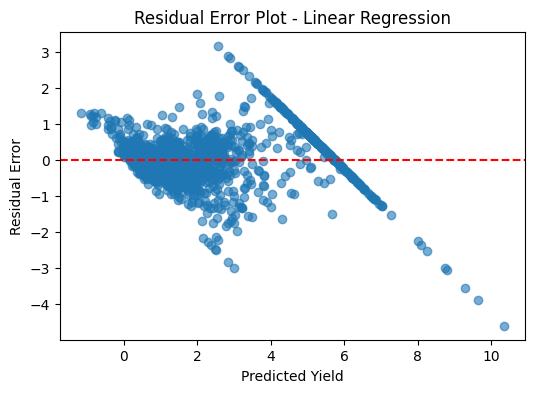

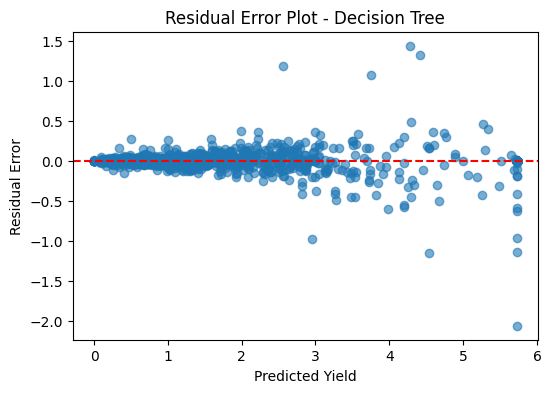

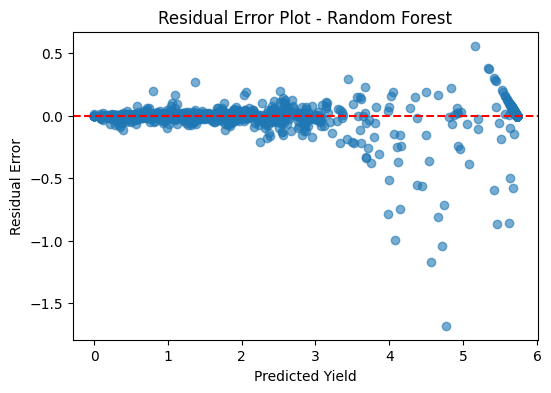

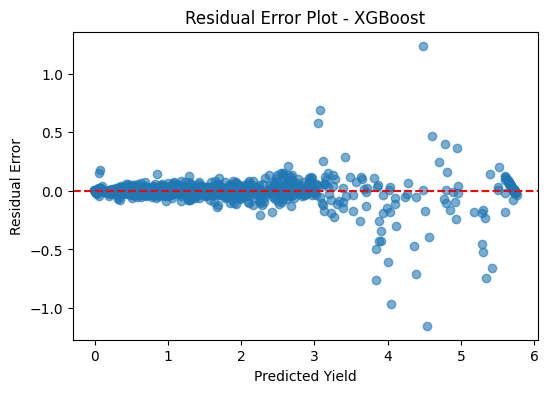

In [ ]:
for model_name, preds in models.items():
    residuals = y_test - preds

    plt.figure(figsize=(6,4))
    plt.scatter(preds, residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel("Predicted Yield")
    plt.ylabel("Residual Error")
    plt.title(f"Residual Error Plot - {model_name}")
    plt.show()

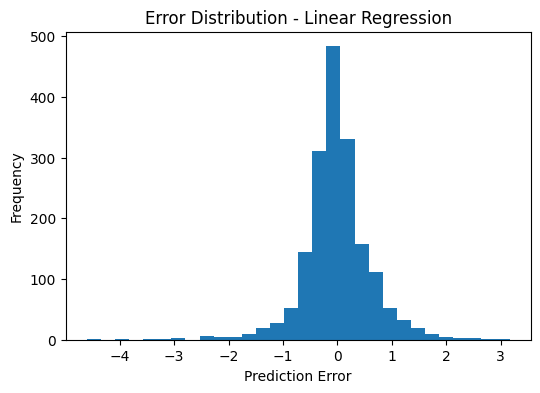

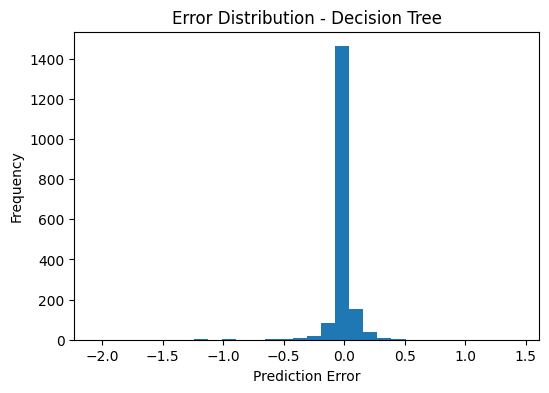

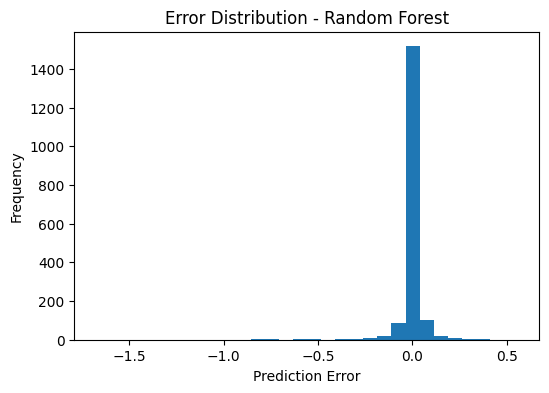

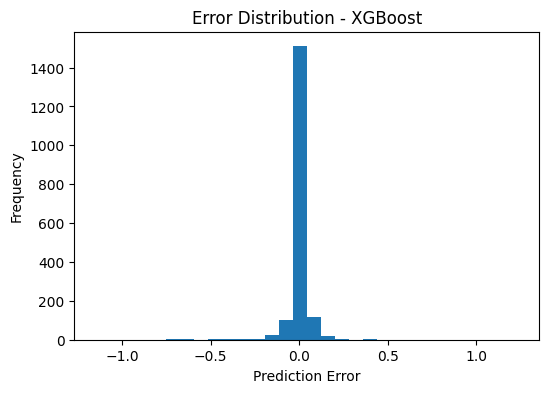

In [ ]:
for model_name, preds in models.items():
    residuals = y_test - preds

    plt.figure(figsize=(6,4))
    plt.hist(residuals, bins=30)
    plt.xlabel("Prediction Error")
    plt.ylabel("Frequency")
    plt.title(f"Error Distribution - {model_name}")
    plt.show()

In [ ]:
best_model = results.sort_values(by="R2 Score", ascending=False).iloc[0]
print("Best Model:", best_model["Model"])
print("Accuracy (%):", best_model["Accuracy (%)"])

Best Model: XGBoost
Accuracy (%): 99.80484737129596


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print("Cross Validation Score:", scores.mean())

Cross Validation Score: 0.9946526136463658


In [ ]:
features = ["State", "crop", "rainfall", "Avg_Temperature", "soil_type", "N", "P", "K", "pH", "Humidity"]
target = "yield"

X = df[features]
y = df[target]

In [ ]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

features = ["State", "crop", "rainfall", "Avg_Temperature", "soil_type", "N", "P", "K", "pH", "Humidity"]
target = "yield"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

categorical_features = ["State", "crop", "soil_type"]
numeric_features = ["rainfall", "Avg_Temperature", "N", "P", "K", "pH", "Humidity"]

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numeric_transformer, numeric_features)
    ]
)

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.36418144816188397
RMSE: 0.5970244024787448
R2: 0.8974694741197068


In [ ]:
import joblib
joblib.dump(pipeline, "best_crop_yield_model.pkl")

['best_crop_yield_model.pkl']

In [ ]:
from google.colab import files
files.download("/content/best_crop_yield_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Creating NPK averages to predict with csv file

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Crop yeild Datsets.csv")

# Keep needed columns
npk_df = df[["State", "crop", "N", "P", "K"]].copy()

# State + Crop averages
state_crop_avg = (
    npk_df.groupby(["State", "crop"], as_index=False)[["N", "P", "K"]]
    .mean()
)

state_crop_avg.to_csv("state_crop_npk_avg.csv", index=False)

# Crop-only averages
crop_avg = (
    npk_df.groupby("crop", as_index=False)[["N", "P", "K"]]
    .mean()
)

crop_avg.to_csv("crop_npk_avg.csv", index=False)

# Overall averages
overall_avg = npk_df[["N", "P", "K"]].mean()
print("Overall averages:")
print(overall_avg)

Overall averages:
N    60.670768
P    27.928901
K    44.989089
dtype: float64


In [ ]:
print(df.columns)

Index(['State', 'Year', 'crop', 'yield', 'rainfall', 'Avg_Temperature', 'Area',
       'Production', 'soil_type', 'Climate_Zone', 'Avg_Summer_Temp_C',
       'Avg_Winter_Temp_C', 'Irrigation_Coverage_%',
       'Groundwater_Availability', 'Cropping_Intensity_%', 'N', 'P', 'K', 'pH',
       'Humidity'],
      dtype='object')
